# Part 1: Install Required Libraries

In [2]:
!pip -q install -U transformers datasets accelerate evaluate openpyxl scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.3/512.3 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 19.2 MB/s eta 0:00:00


In [3]:
!pip -q install -U transformers accelerate datasets scikit-learn pandas openpyxl evaluate
!pip -q install -U openai-whisper gTTS
!apt-get -qq install -y ffmpeg


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 53.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 16.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 7.1 MB/s eta 0:00:00


In [4]:
!pip install evaluate


In [5]:
import pandas as pd
from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
import torch
import evaluate
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Part 2: Load and Prepare the Dataset

In [ ]:
 # if u upload it with files use this
from google.colab import files

#  Upload dataset
print("Upload your dataset:")
uploaded = files.upload()  # Upload dataset
DATA_FILE_PATH = list(uploaded.keys())[0]

Upload your dataset:


Saving combined_first_aid_data_shuffled.xlsx to combined_first_aid_data_shuffled.xlsx


In [7]:
def load_and_prepare_data(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    df["COMPOSITE_LABEL"] = (
        df["label"].astype(str)
        + " (" + df["severity"].astype(str) + ")"
    )

    df["ML_INPUT"] = (
        df["user_phrases"].astype(str)
        + " [Scenario: " + df["scenario"].astype(str) + "]"
        + " [Age Group: " + df["age_group"].astype(str) + "]"
    )

    labels = df["COMPOSITE_LABEL"].unique().tolist()
    label_to_id = {label: i for i, label in enumerate(labels)}
    id_to_label = {i: label for label, i in label_to_id.items()}
    df["labels"] = df["COMPOSITE_LABEL"].map(label_to_id)

    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        random_state=42,
        stratify=df["labels"]
    )

    train_dataset = Dataset.from_pandas(train_df[["ML_INPUT", "labels"]].reset_index(drop=True))
    test_dataset  = Dataset.from_pandas(test_df[["ML_INPUT", "labels"]].reset_index(drop=True))

    return train_dataset, test_dataset, label_to_id, id_to_label

In [8]:
train_dataset, test_dataset, label_to_id, id_to_label = load_and_prepare_data(DATA_FILE_PATH)
for idx, label in id_to_label.items():
    print(idx, "→", label)

0 → حرق (خفيف)
1 → جرح (عالي)
2 → اختناق (متوسط)
3 → الرعاف (متوسط)
4 → الرعاف (خفيف)
5 → حرق (متوسط)
6 → اختناق (عالي)
7 → جرح (خفيف)
8 → حرق (عالي)
9 → جرح (متوسط)
10 → اختناق (خفيف)


#  Part 3: Tokenization (Text → Numeric Tokens)

In [9]:
# Model name
MODEL_NAME = "aubmindlab/bert-base-arabertv2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Tokenizer
def tokenize_function(examples):
    return tokenizer(
        examples["ML_INPUT"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset  = test_dataset.map(tokenize_function, batched=True)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/480 [00:00<?, ? examples/s]

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

# Part 4: Model Initialization & Training

In [10]:
import numpy as np
import evaluate
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments

# Metrics
metric_f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return metric_f1.compute(predictions=preds, references=labels, average="macro")

# Model
num_labels = len(label_to_id)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id_to_label,
    label2id=label_to_id
)

# Training arguments
training_args = TrainingArguments(
    output_dir="./arabert_results",
    num_train_epochs=7,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir="./arabert_logs",
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4221891126.py:41: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


* Train the model

In [11]:
# Train
print("Starting AraBERT Fine-Tuning...")
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 31}.


Starting AraBERT Fine-Tuning...


Epoch,Training Loss,Validation Loss,F1
1,2.144800,2.007434,0.154053
2,1.552900,1.375007,0.318636
3,0.932000,0.925562,0.389070
4,0.631700,0.591524,0.553763
5,0.539100,0.484800,0.709726
6,0.254100,0.389481,0.748608
7,0.260400,0.405867,0.848352


TrainOutput(global_step=420, training_loss=1.0241602528662908, metrics={'train_runtime': 195.3377, 'train_samples_per_second': 17.201, 'train_steps_per_second': 2.15, 'total_flos': 221031146004480.0, 'train_loss': 1.0241602528662908, 'epoch': 7.0})

* Save the model

In [12]:
print("Final Evaluation...")
eval_results = trainer.evaluate()
print(eval_results)

model_save_path = "./final_arabert_model"
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

print(f"✅ Model saved to: {model_save_path}")

Final Evaluation...


{'eval_loss': 0.40586692094802856, 'eval_f1': 0.8483516483516482, 'eval_runtime': 0.8485, 'eval_samples_per_second': 141.423, 'eval_steps_per_second': 17.678, 'epoch': 7.0}
✅ Model saved to: ./final_arabert_model


# Part 5: Classification Report & Confusion Matrix

/tmp/ipython-input-1394086113.py:12: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_eval = Trainer(


Classification Report:

                precision    recall  f1-score   support

    حرق (خفيف)       1.00      1.00      1.00         9
    جرح (عالي)       1.00      1.00      1.00         6
اختناق (متوسط)       1.00      1.00      1.00        26
الرعاف (متوسط)       0.00      0.00      0.00         8
 الرعاف (خفيف)       0.73      1.00      0.85        22
   حرق (متوسط)       1.00      1.00      1.00        12
 اختناق (عالي)       1.00      1.00      1.00         3
    جرح (خفيف)       0.73      0.85      0.79        13
    حرق (عالي)       1.00      1.00      1.00         9
   جرح (متوسط)       0.78      0.64      0.70        11
 اختناق (خفيف)       1.00      1.00      1.00         1

      accuracy                           0.88       120
     macro avg       0.84      0.86      0.85       120
  weighted avg       0.84      0.88      0.85       120



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


<Figure size 1200x1000 with 0 Axes>

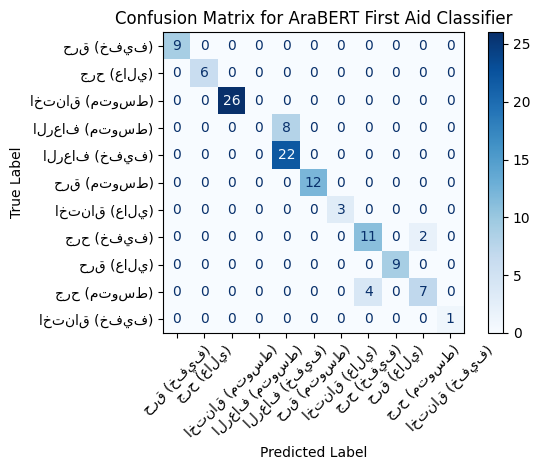

In [13]:
from transformers import Trainer, TrainingArguments

eval_args = TrainingArguments(
    output_dir="./results_eval",
    per_device_eval_batch_size=8,
    do_train=False,
    do_eval=True,
    logging_dir="./logs_eval",
    report_to="none"
)

trainer_eval = Trainer(
    model=model,  # pre-train model
    args=eval_args,
    eval_dataset=tokenized_test_dataset,
    tokenizer=tokenizer
)

predictions = trainer_eval.predict(tokenized_test_dataset)

y_pred = predictions.predictions.argmax(axis=-1)
y_true = predictions.label_ids

from sklearn.metrics import classification_report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(label_to_id.keys())))

cm = confusion_matrix(y_true, y_pred)
labels = list(label_to_id.keys())

plt.figure(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues, values_format='d')

plt.title("Confusion Matrix for AraBERT First Aid Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#  Part 6: End-to-End System( Deploy ASR → NLP → KB → TTS pipeline)

In [17]:
!pip install --upgrade elevenlabs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.3 MB/s eta 0:00:00


In [18]:
!pip install elevenlabs

Building ASR model

In [ ]:
import whisper
from gtts import gTTS
from IPython.display import Audio, display

# 1) Load Whisper ASR model once
asr = whisper.load_model("small")  # لو تبينه أسرع: "base"

# 2) Load your fine-tuned AraBERT model
clf_model_path = "./final_arabert_model"
clf_model = AutoModelForSequenceClassification.from_pretrained(clf_model_path)
clf_tokenizer = AutoTokenizer.from_pretrained(clf_model_path)

# 3) Build First Aid Knowledge Base from the same Excel file
kb_df = pd.read_excel(DATA_FILE_PATH, engine="openpyxl")
kb_df["COMPOSITE_LABEL"] = kb_df["label"].astype(str) + " (" + kb_df["severity"].astype(str) + ")"
first_aid_steps = dict(zip(kb_df["COMPOSITE_LABEL"], kb_df["first_aid_steps"]))

print(" ASR + NLP model + KB loaded successfully")


 ASR + NLP model + KB loaded successfully


In [116]:
def speech_to_text(audio_path: str) -> str:
    result = asr.transcribe(audio_path, language="ar")
    return result["text"].strip()

def classify_text(text: str):
    inputs = clf_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )
    with torch.no_grad():
        outputs = clf_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)

    pred_id = probs.argmax(dim=-1).item()
    conf = probs.max().item()
    pred_label = id_to_label[pred_id]     #  mapping from your training cell
    return pred_label, conf


* Input file apload

In [117]:
from google.colab import files

uploaded_audio = files.upload()   # ارفعي ملف صوتي
audio_path = list(uploaded_audio.keys())[0]

# STT and print transcribed text
user_text = speech_to_text(audio_path)
print("Transcribed text:", user_text)

Saving ii.aac to ii.aac
Transcribed text: أثناء تنظيف أدوات الشوا إنجرح من الشبك المعدني


* Word Importance using TF-IDF

In [130]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import re

def arabic_word_tokenizer(text):
    # Keep only Arabic letters and spaces
    text = re.sub(r"[^ء-ي\s]", " ", text)
    return text.split()

# 1. Prepare corpus
corpus = list(train_dataset["ML_INPUT"]) + [user_text]

# 2. Fit TF‑IDF with custom tokenizer
vectorizer = TfidfVectorizer(tokenizer=arabic_word_tokenizer)
tfidf_matrix = vectorizer.fit_transform(corpus)

# 3. Extract user TF‑IDF
user_tfidf = tfidf_matrix[-1].toarray()[0]

# 4. Map tokens to scores
feature_names = vectorizer.get_feature_names_out()
token_scores = list(zip(feature_names, user_tfidf))

# 5. Filter & sort
token_scores = [(tok, score) for tok, score in token_scores if score > 0]
token_scores = sorted(token_scores, key=lambda x: x[1], reverse=True)

# 6. Print
for token, score in token_scores:
    print(f"Word: {token}, Importance (TF-IDF): {score:.4f}")

Word: إنجرح, Importance (TF-IDF): 0.4484
Word: الشوا, Importance (TF-IDF): 0.4484
Word: الشبك, Importance (TF-IDF): 0.4204
Word: المعدني, Importance (TF-IDF): 0.4204
Word: أدوات, Importance (TF-IDF): 0.3526
Word: تنظيف, Importance (TF-IDF): 0.2766
Word: من, Importance (TF-IDF): 0.1522
Word: أثناء, Importance (TF-IDF): 0.1429


# **Generate Response**

1.   Needed Functions for TTS model

In [119]:
def classify_text(text):
    inputs = clf_tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    with torch.no_grad():
        outputs = clf_model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        pred_label = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][pred_label].item()

    return pred_label, confidence

In [120]:
def get_severity(label_id):
    composite_label = id_to_label[label_id]
    if "(" in composite_label and ")" in composite_label:
        severity = composite_label.split("(")[-1].split(")")[0].strip()
        return severity
    return "Unknown"

In [121]:
def text_to_speech_ar(text, output_file):
    audio_gen = client.text_to_speech.convert(
        text=text,
        voice_id="JBFqnCBsd6RMkjVDRZzb",
        model_id="eleven_multilingual_v2"
    )
    audio_bytes = b"".join(audio_gen)
    with open(output_file, "wb") as f:
        f.write(audio_bytes)
    return output_file

2.   Setup Responser and transcribe input



In [122]:
import os

os.environ["ELEVENLABS_API_KEY"] = "sk_5d9a7ba260acbaada6c55b5214fec7162f5be920d23f9592"

from elevenlabs import ElevenLabs
client = ElevenLabs(api_key=os.environ["ELEVENLABS_API_KEY"])

# Classification (using full text, not TF-IDF cleaned text)
pred_label, conf = classify_text(user_text)

# Severity extraction
severity = get_severity(pred_label)

3.   Execute and respond (With confirm prediction)

In [125]:
def get_first_aid_response(label_id, token_scores, top_k=4):
    # Load knowledge base
    kb_df = pd.read_excel(DATA_FILE_PATH, engine="openpyxl")
    kb_df["COMPOSITE_LABEL"] = (
        kb_df["label"].astype(str) + " (" + kb_df["severity"].astype(str) + ")"
    )

    # Extract predicted composite label
    composite_label = id_to_label[label_id]

    # Filter KB to ONLY this label type
    filtered_kb = kb_df[kb_df["COMPOSITE_LABEL"] == composite_label].copy()

    # If no TF-IDF provided, return base response
    if token_scores is None or len(token_scores) == 0:
        return filtered_kb["first_aid_steps"].iloc[0]

    # Extract important words
    important_words = [w for w, s in token_scores[:top_k]]

    # Build search text
    filtered_kb["SEARCH_TEXT"] = (
        filtered_kb["scenario"].astype(str) + " " +
        filtered_kb["first_aid_steps"].astype(str)
    )

    # Score entries by important word matches
    def score_entry(text):
        return sum(1 for w in important_words if w in text)

    filtered_kb["MATCH_SCORE"] = filtered_kb["SEARCH_TEXT"].apply(score_entry)

    # Pick best match within the same label category
    best_row = filtered_kb.sort_values("MATCH_SCORE", ascending=False).iloc[0]

    # Build final response
    enhanced_response = enhanced_response = best_row["first_aid_steps"]

    return enhanced_response

In [126]:

print("Transcribed text from audio:", user_text)
print("Predicted label:", id_to_label[pred_label])
print("Confidence:", round(conf, 4))
print("Severity level:", severity)

user_confirm = input("هل التصنيف صحيح؟ (نعم/لا): ").strip().lower()

if user_confirm == "نعم":
    response_text = get_first_aid_response(pred_label, token_scores)
    out_audio = text_to_speech_ar(response_text, "first_aid_response.mp3")
    print("Text response:", response_text)
    display(Audio(out_audio))
else:
    print("تم إيقاف الرد الصوتي. الرجاء إعادة رفع الصوت.")

Transcribed text from audio: أثناء تنظيف أدوات الشوا إنجرح من الشبك المعدني
Predicted label: جرح (خفيف)
Confidence: 0.973
Severity level: خفيف
هل التصنيف صحيح؟ (نعم/لا):  نعم
Text response: اضغط لوقف النزيف. نظف الجرح جيداً بالماء والصابون (تجنب دخول الصابون للجرح). غطِّ الجرح بضمادة بسيطة.
